In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
### FUNCTION LIBRARY ###
def read_csv_file(file_path):
    values = []
    with open(file_path, 'r') as file:
        reader = csv.reader(file)
        for row in reader:
            values.extend(row)
    return values

# Plot GRUAN Meteorological Data

In [3]:
# Provide the path to your CSV file
mld_file_path = '/home/chinahg/GCresearch/contrailuncertainty/GRUAN_processing/GRUAN_MLD.csv'
rh_file_path = '/home/chinahg/GCresearch/contrailuncertainty/GRUAN_processing/GRUAN_RH.csv'

# Call the function to read the CSV file
GRUAN_MLD = np.array(read_csv_file(mld_file_path), dtype = float)
GRUAN_cruiseRH = np.array(read_csv_file(rh_file_path), dtype = float)

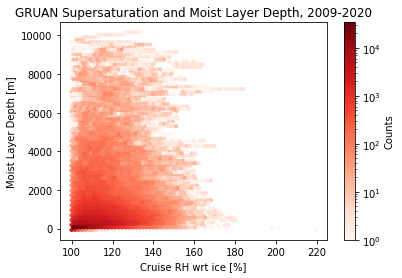

In [4]:
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots()
hb = ax.hexbin(x = GRUAN_cruiseRH, y = GRUAN_MLD, gridsize = 70, cmap = 'Reds', mincnt=1, bins='log')
ax.set_title("GRUAN Supersaturation and Moist Layer Depth, 2009-2020")
plt.xlabel("Cruise RH wrt ice [%]")
plt.ylabel("Moist Layer Depth [m]")
cb = fig.colorbar(hb, ax=ax, label='Counts')
plt.show()

# Plot ERA5 Meteorological Data

In [5]:
# Provide the path to your CSV file
mld_file_path = '/home/chinahg/GCresearch/contrailuncertainty/ERA5_processing/ERA5_MLD.csv'
rh_file_path = '/home/chinahg/GCresearch/contrailuncertainty/ERA5_processing/ERA5_RH.csv'

# Call the function to read the CSV file
ERA5_MLD = np.array(read_csv_file(mld_file_path), dtype = float)
ERA5_cruiseRH = np.array(read_csv_file(rh_file_path), dtype = float)

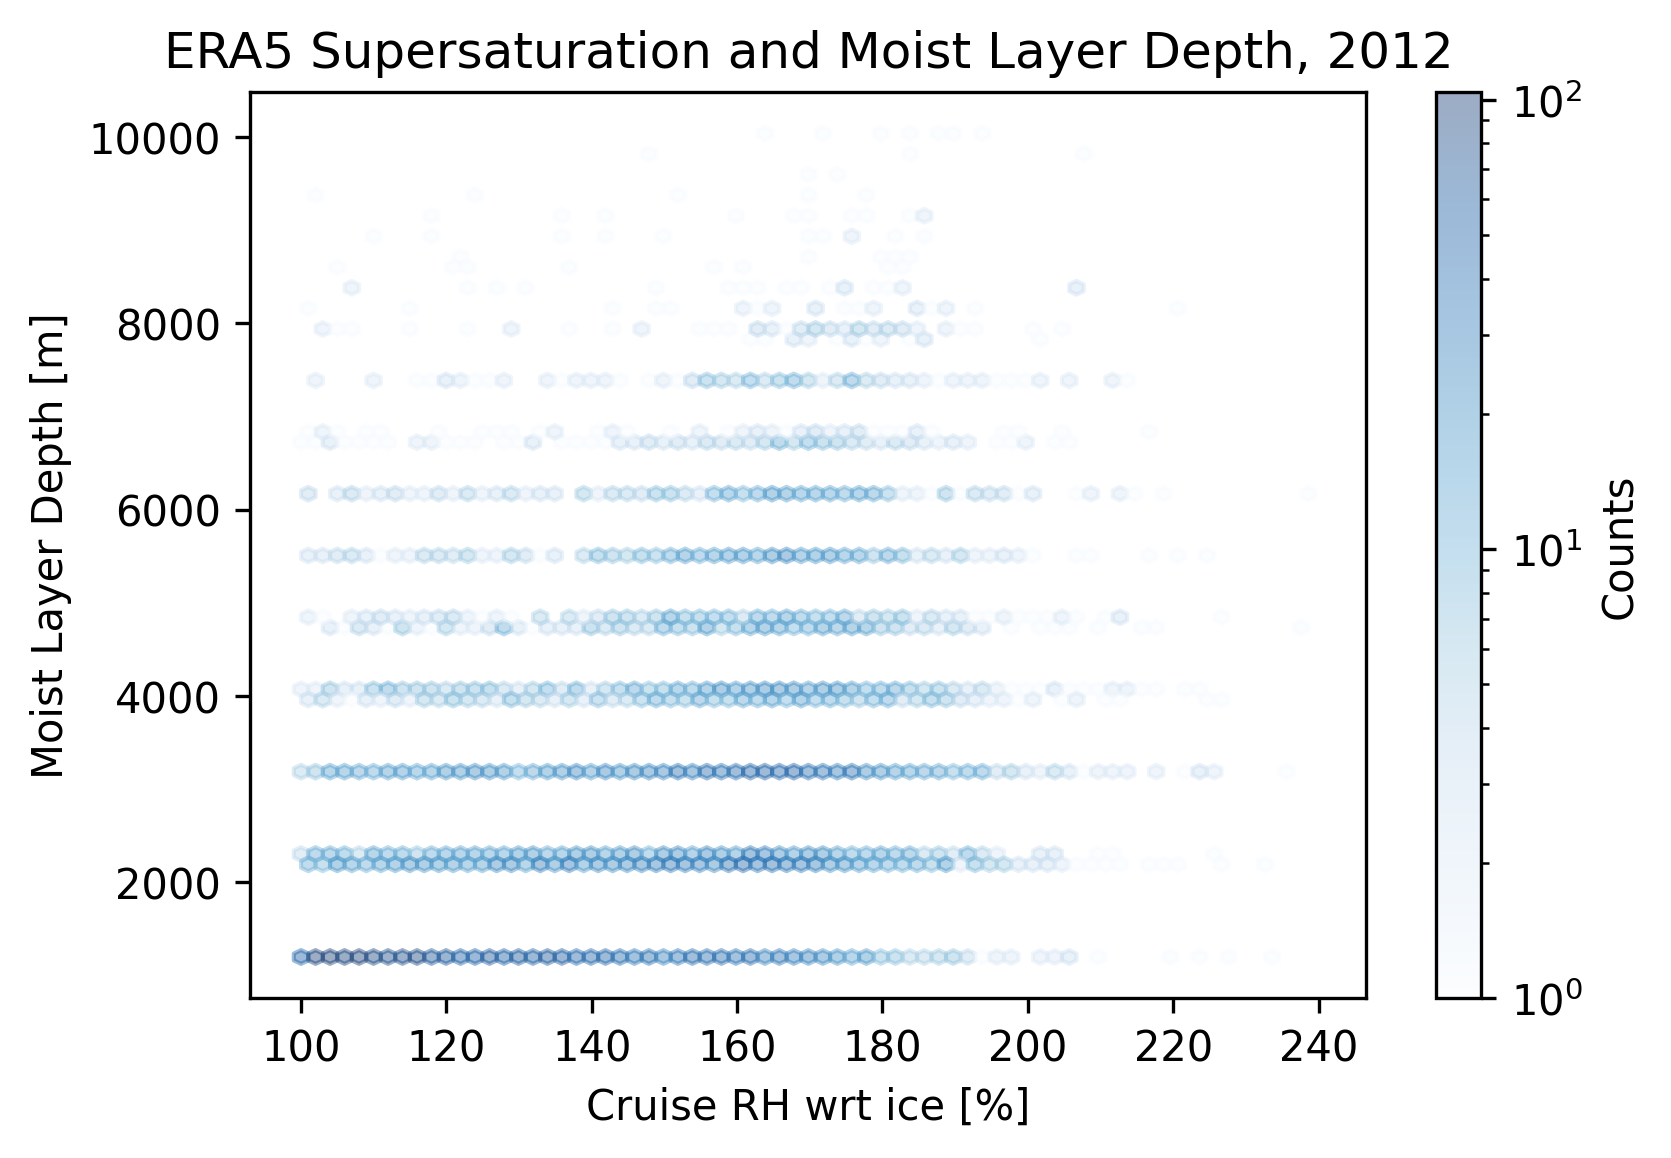

In [6]:
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots()
hb = ax.hexbin(x = ERA5_cruiseRH, y = ERA5_MLD, gridsize = 70, cmap = 'Blues', mincnt=1, bins='log', alpha=0.4)
ax.set_title("ERA5 Supersaturation and Moist Layer Depth, 2012")
plt.xlabel("Cruise RH wrt ice [%]")
plt.ylabel("Moist Layer Depth [m]")
cb = fig.colorbar(hb, ax=ax, label='Counts')
plt.show()

# Plot ERA5 vs GRUAN Meteorological Data

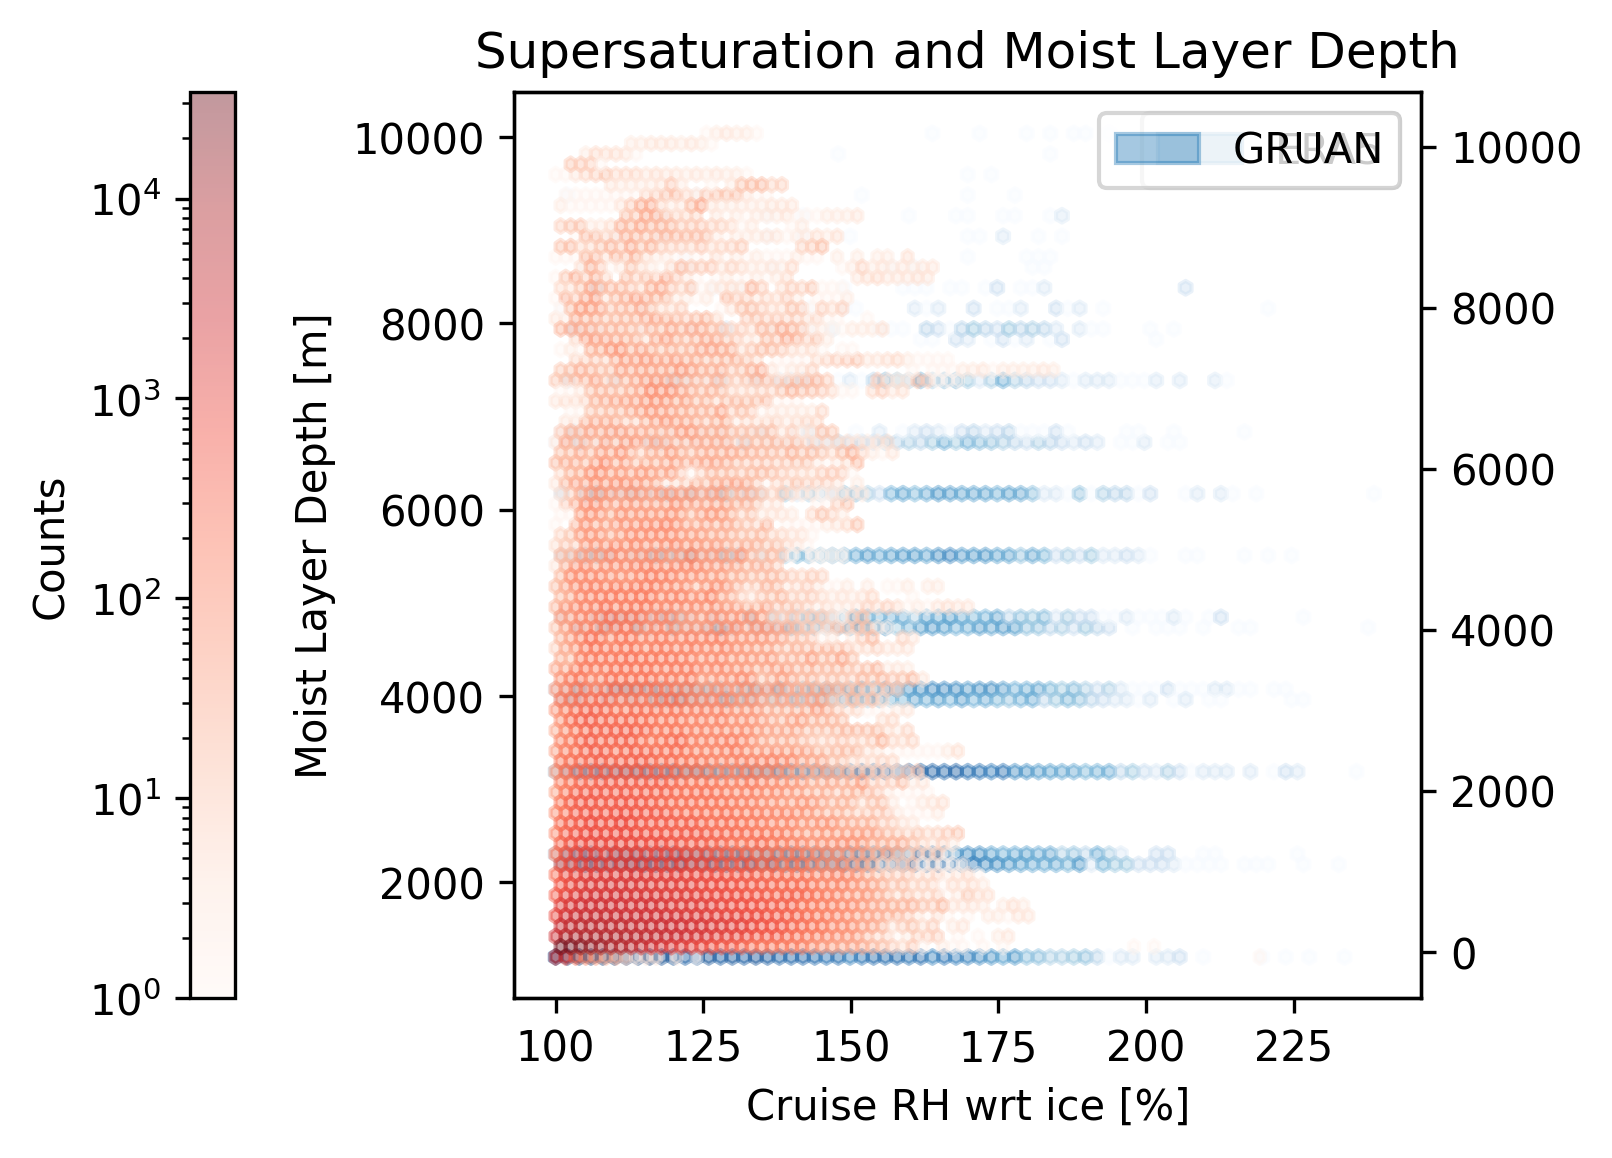

In [7]:
plt.rcParams['figure.dpi'] = 300

fig, ax1  = plt.subplots()
ax2 = ax1.twinx()
hb1 = ax1.hexbin(x = ERA5_cruiseRH, y = ERA5_MLD, gridsize = 70, cmap = 'Blues', mincnt=1, bins='log', 
                 label='ERA5', alpha=0.4)
hb2 = ax2.hexbin(x = GRUAN_cruiseRH, y = GRUAN_MLD, gridsize = 70, cmap = 'Reds', mincnt=1, bins='log', 
                 label='GRUAN', alpha=0.4)
ax1.set_title("Supersaturation and Moist Layer Depth")
ax1.set_xlabel("Cruise RH wrt ice [%]")
ax1.set_ylabel("Moist Layer Depth [m]")
ax1.legend()
ax2.legend()
# cb1 = fig.colorbar(hb1, ax=ax1, pad = 0.99, location='right')
cb2 = fig.colorbar(hb2, ax=ax2, pad = 0.2, label='Counts', location='left')
plt.show()

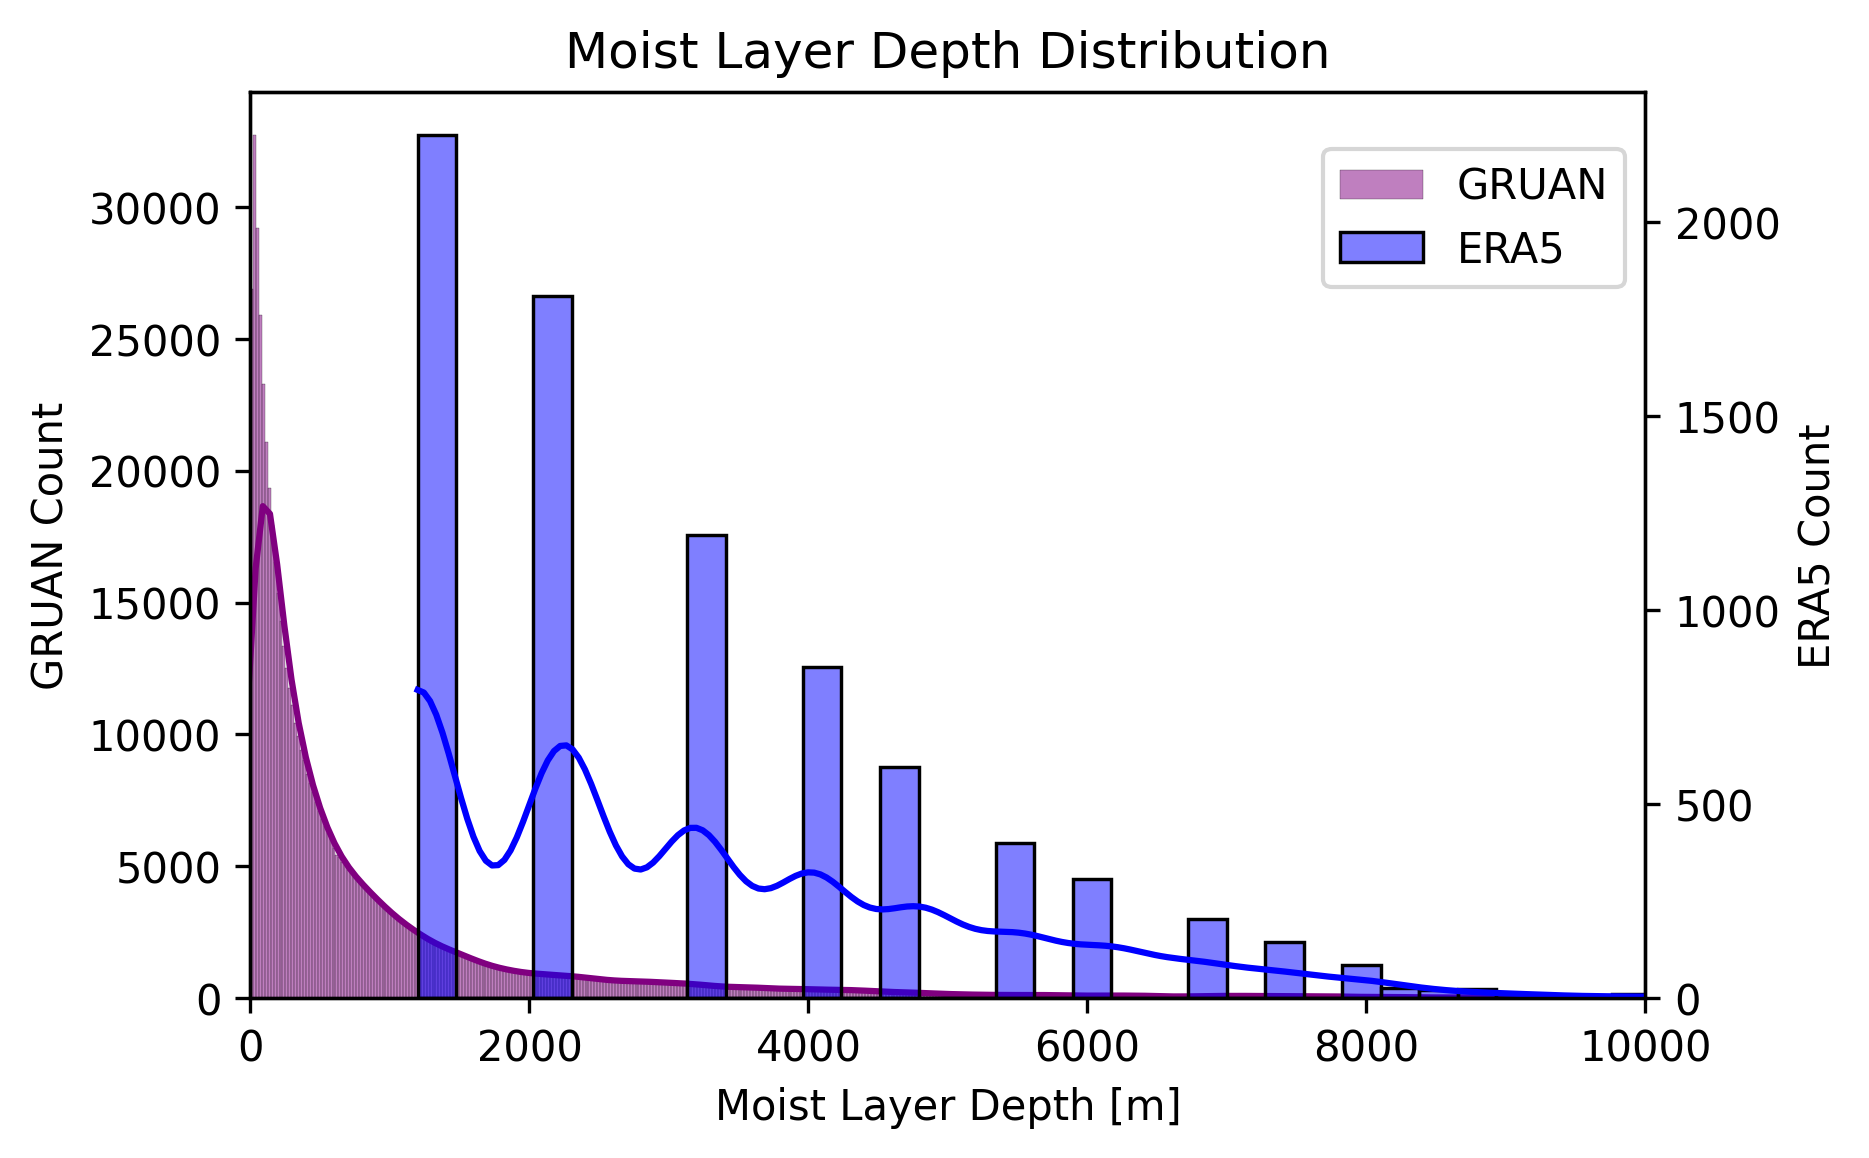

In [18]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax1 = ax.twinx()
sns.histplot(GRUAN_MLD, ax = ax, kde=True, label = 'GRUAN', color='purple')
sns.histplot(ERA5_MLD, ax = ax1, kde=True, label = 'ERA5', color='blue')
ax.set_xlabel("Moist Layer Depth [m]")
ax1.set_xlim(0,10000)
plt.title("Moist Layer Depth Distribution")
ax.set_ylabel("GRUAN Count")
ax1.set_ylabel("ERA5 Count")
fig.legend(bbox_to_anchor=(0.9, 0.85)) # x, y, width, height

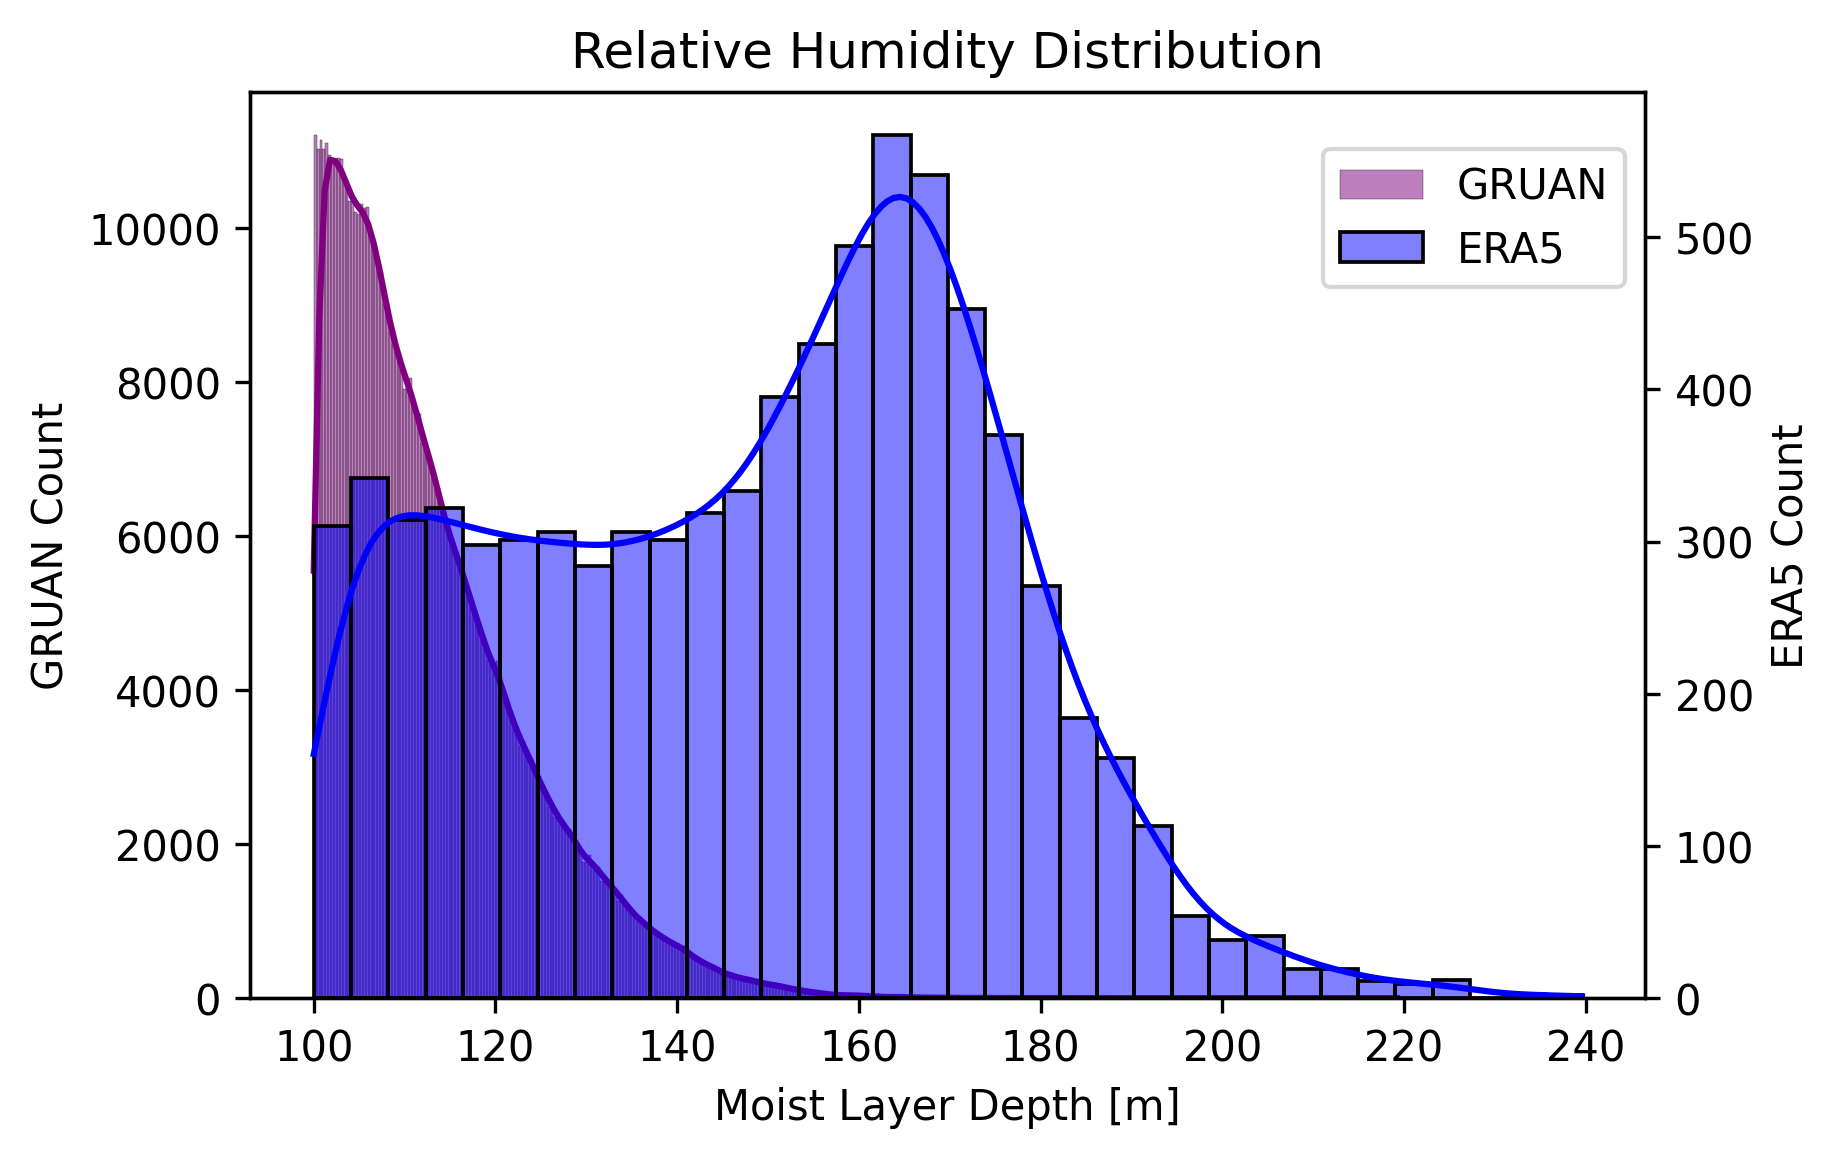

In [9]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax1 = ax.twinx()
sns.histplot(GRUAN_cruiseRH, ax = ax, kde=True, label = 'GRUAN', color='purple')
sns.histplot(ERA5_cruiseRH, ax = ax1, kde=True, label = 'ERA5', color='blue')
ax.set_xlabel("Moist Layer Depth [m]")
plt.title("Relative Humidity Distribution")
ax.set_ylabel("GRUAN Count")
ax1.set_ylabel("ERA5 Count")
fig.legend(bbox_to_anchor=(0.9, 0.85)) # x, y, width, height

# Calculate KL-Divergence between the two distributions

In [10]:
def norm_kl_divergence(a, b): # a is treated as the "true" distribution
    KL_div = np.abs(np.sum(a * np.log(a/b)))/len(a)
    return KL_div
def delete_negative_values(arr):
    return arr[arr >= 0]

GRUAN_MLD_no_neg = delete_negative_values(GRUAN_MLD)
ERA5_MLD_no_neg = delete_negative_values(ERA5_MLD)
GRUAN_RH_no_neg = delete_negative_values(GRUAN_cruiseRH)
ERA5_RH_no_neg = delete_negative_values(GRUAN_cruiseRH)

num_samples = 1000000
rand_GRUAN_MLD = np.random.choice(GRUAN_MLD_no_neg, size = num_samples)
rand_ERA5_MLD = np.random.choice(ERA5_MLD_no_neg, size = num_samples)
rand_GRUAN_RH = np.random.choice(GRUAN_RH_no_neg, size = num_samples)
rand_ERA5_RH = np.random.choice(ERA5_RH_no_neg, size = num_samples)

MLD_norm_kl_div = norm_kl_divergence(rand_GRUAN_MLD, rand_ERA5_MLD)
RH_norm_kl_div = norm_kl_divergence(rand_GRUAN_RH, rand_ERA5_RH)

print("Bits required per MLD datapoint", MLD_norm_kl_div)
print("Bits required per RH datapoint", RH_norm_kl_div)

Bits required per MLD datapoint 303.93085064076274
Bits required per RH datapoint 0.941918310215018
